In [207]:
gdf = gpd.read_file("land_use/hoodgdf.gpkg")
gdf.head()

,Name,sidewalk_index,bike_index,cartway_density_index,ndvi_score,park_proximity_score,tree_score,health_proximity_score,service_proximity_score,geometry
0,LAWNDALE,0.981667,0.201329,0.633628,0.356519,0.886946,0.000000,0.871489,0.892003,"POLYGON ((-75.08616 40.05013, -75.08893 40.044..."
1,ASTON_WOODBRIDGE,0.946746,0.201768,0.682118,0.560973,0.437272,0.000000,0.788306,0.646258,"POLYGON ((-75.0086 40.05369, -75.00861 40.0535..."
2,CARROLL_PARK,0.964426,0.190563,0.735923,0.266218,0.823277,0.064336,0.892550,0.879310,"POLYGON ((-75.22673 39.9772, -75.22022 39.9742..."
3,CHESTNUT_HILL,0.950545,0.022636,0.439744,0.804823,0.713442,0.000000,0.810931,0.812973,"POLYGON ((-75.21278 40.08637, -75.21272 40.086..."
4,BURNHOLME,0.923102,0.145879,0.864792,0.566354,0.759824,0.044473,0.846795,0.806047,"POLYGON ((-75.08768 40.06861, -75.08758 40.068..."


In [208]:
gdf_mobility= gpd.read_file("census/gdf_mobility.gpkg")

In [209]:
import geopandas as gpd

# Ensure CRS match
gdf = gdf.to_crs(epsg=4326)           # neighborhoods
gdf_mobility = gdf_mobility.to_crs(epsg=4326)  # tracts

# Perform spatial join: tracts get neighborhood Name
joined = gpd.sjoin(
    gdf_mobility,                  # tracts
    gdf[['Name','geometry']],      # neighborhoods
    how='left',
    predicate='intersects'
)

# Drop sjoin helper column
joined = joined.drop(columns=['index_right'], errors='ignore')

# Numeric tract variables to average
tract_vars = ['age_65_plus_rate_inv','disability_rate_inv','commute_walk_rate']  # etc.

# Group by neighborhood Name to get one row per neighborhood
neigh_agg = joined.groupby('Name')[tract_vars].mean().reset_index()

# Merge back into gdf without creating _x/_y
gdf = gdf.merge(neigh_agg, on='Name', how='left')

gdf.head()


,Name,sidewalk_index,bike_index,cartway_density_index,ndvi_score,park_proximity_score,tree_score,health_proximity_score,service_proximity_score,geometry,age_65_plus_rate_inv,disability_rate_inv,commute_walk_rate
0,LAWNDALE,0.981667,0.201329,0.633628,0.356519,0.886946,0.000000,0.871489,0.892003,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...",0.835755,0.688035,0.000160
1,ASTON_WOODBRIDGE,0.946746,0.201768,0.682118,0.560973,0.437272,0.000000,0.788306,0.646258,"POLYGON ((-75.0086 40.05369, -75.00861 40.0535...",0.782365,0.803854,0.025380
2,CARROLL_PARK,0.964426,0.190563,0.735923,0.266218,0.823277,0.064336,0.892550,0.879310,"POLYGON ((-75.22673 39.9772, -75.22022 39.9742...",0.818437,0.679972,0.044255
3,CHESTNUT_HILL,0.950545,0.022636,0.439744,0.804823,0.713442,0.000000,0.810931,0.812973,"POLYGON ((-75.21278 40.08637, -75.21272 40.086...",0.722637,0.773337,0.032959
4,BURNHOLME,0.923102,0.145879,0.864792,0.566354,0.759824,0.044473,0.846795,0.806047,"POLYGON ((-75.08768 40.06861, -75.08758 40.068...",0.795103,0.892218,0.000000


In [177]:
gdf.head()

,age_65_plus_rate_inv,disability_rate_inv,commute_walk_rate,GEOID,geometry,index_right,Name,sidewalk_index,bike_index,cartway_density_index,ndvi_score,park_proximity_score,tree_score,health_proximity_score,service_proximity_score
0,0.899890,0.654230,0.000000,42101000101,"POLYGON ((-75.15221 39.94997, -75.15203 39.950...",100,OLD_CITY,0.983893,0.571690,0.632752,0.179786,0.912035,0.000000,0.916745,0.958680
1,0.871467,0.835888,0.041853,42101000102,"POLYGON ((-75.15155 39.95544, -75.15148 39.955...",100,OLD_CITY,0.983893,0.571690,0.632752,0.179786,0.912035,0.000000,0.916745,0.958680
1,0.871467,0.835888,0.041853,42101000102,"POLYGON ((-75.15155 39.95544, -75.15148 39.955...",126,CALLOW_HILL,0.990299,0.731513,0.951865,0.082745,0.959372,0.442092,0.880013,0.936431
1,0.871467,0.835888,0.041853,42101000102,"POLYGON ((-75.15155 39.95544, -75.15148 39.955...",142,NORTHERN_LIBERTIES,0.999174,0.356992,0.875220,0.098821,0.900411,0.179824,0.833487,0.798390
2,0.834920,1.000000,0.000000,42101000200,"POLYGON ((-75.16289 39.95533, -75.16269 39.956...",100,OLD_CITY,0.983893,0.571690,0.632752,0.179786,0.912035,0.000000,0.916745,0.958680


In [210]:
# Mobility Score
gdf["mobility_score"] = gdf[[
    "cartway_density_index",  # curb_density_index
    "sidewalk_index",
    "bike_index"
]].mean(axis=1)

# Environmental Score
gdf["environmental_score"] = gdf[[
    "park_proximity_score",
    "tree_score",
    "ndvi_score"
]].mean(axis=1)

# Land Use Score
gdf["land_use_score"] = gdf[[
    "health_proximity_score",
    "service_proximity_score"
]].mean(axis=1)

# Social Score
gdf["social_score"] = gdf[[
    "age_65_plus_rate_inv",  # elderly index
    "disability_rate_inv",   # disability index
    "commute_walk_rate"      # walk commute index
]].mean(axis=1)


In [211]:
weights = {
    "mobility_score": 0.4,      # highest
    "land_use_score": 0.3,
    "environmental_score": 0.2,
    "social_score": 0.1          # lowest
}


In [212]:
gdf["accessibility_score"] = (
    gdf["mobility_score"] * weights["mobility_score"] +
    gdf["land_use_score"] * weights["land_use_score"] +
    gdf["environmental_score"] * weights["environmental_score"] +
    gdf["social_score"] * weights["social_score"]
)


In [213]:
import geopandas as gpd

gdf.head()

,Name,sidewalk_index,bike_index,cartway_density_index,ndvi_score,park_proximity_score,tree_score,health_proximity_score,service_proximity_score,geometry,age_65_plus_rate_inv,disability_rate_inv,commute_walk_rate,mobility_score,environmental_score,land_use_score,social_score,accessibility_score
0,LAWNDALE,0.981667,0.201329,0.633628,0.356519,0.886946,0.000000,0.871489,0.892003,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...",0.835755,0.688035,0.000160,0.605541,0.414488,0.881746,0.507983,0.640436
1,ASTON_WOODBRIDGE,0.946746,0.201768,0.682118,0.560973,0.437272,0.000000,0.788306,0.646258,"POLYGON ((-75.0086 40.05369, -75.00861 40.0535...",0.782365,0.803854,0.025380,0.610211,0.332748,0.717282,0.537200,0.579539
2,CARROLL_PARK,0.964426,0.190563,0.735923,0.266218,0.823277,0.064336,0.892550,0.879310,"POLYGON ((-75.22673 39.9772, -75.22022 39.9742...",0.818437,0.679972,0.044255,0.630304,0.384610,0.885930,0.514221,0.646245
3,CHESTNUT_HILL,0.950545,0.022636,0.439744,0.804823,0.713442,0.000000,0.810931,0.812973,"POLYGON ((-75.21278 40.08637, -75.21272 40.086...",0.722637,0.773337,0.032959,0.470975,0.506088,0.811952,0.509644,0.584158
4,BURNHOLME,0.923102,0.145879,0.864792,0.566354,0.759824,0.044473,0.846795,0.806047,"POLYGON ((-75.08768 40.06861, -75.08758 40.068...",0.795103,0.892218,0.000000,0.644591,0.456883,0.826421,0.562440,0.653383


In [216]:
gdf_mean = gdf.drop(columns="geometry").mean(numeric_only=True)
print(gdf_mean)


sidewalk_index             0.920792
bike_index                 0.257783
cartway_density_index      0.708225
ndvi_score                 0.349628
park_proximity_score       0.817475
tree_score                 0.065664
health_proximity_score     0.796829
service_proximity_score    0.788007
age_65_plus_rate_inv       0.803684
disability_rate_inv        0.783729
commute_walk_rate          0.095819
mobility_score             0.627257
environmental_score        0.410922
land_use_score             0.792418
social_score               0.561077
accessibility_score        0.629411
dtype: float64


In [217]:
passyunk = gdf[gdf["Name"] == "PASSYUNK_SQUARE"]


In [219]:
passyunk

,Name,sidewalk_index,bike_index,cartway_density_index,ndvi_score,park_proximity_score,tree_score,health_proximity_score,service_proximity_score,geometry,age_65_plus_rate_inv,disability_rate_inv,commute_walk_rate,mobility_score,environmental_score,land_use_score,social_score,accessibility_score
152,PASSYUNK_SQUARE,0.925364,0.288546,0.717006,0.106255,0.906811,0.0,0.933841,0.980857,"POLYGON ((-75.15655 39.93021, -75.15681 39.929...",0.851962,0.83841,0.539611,0.643639,0.337689,0.957349,0.743328,0.686531


In [221]:
# Max accessibility score
max_row = gdf.loc[gdf['accessibility_score'].idxmax()]
print("Max Accessibility Score:")
print(max_row)

# Min accessibility score
min_row = gdf.loc[gdf['accessibility_score'].idxmin()]
print("\nMin Accessibility Score:")
print(min_row)


Max Accessibility Score:
Name                                                           SPRING_GARDEN
sidewalk_index                                                      1.003851
bike_index                                                          0.810195
cartway_density_index                                               0.939535
ndvi_score                                                          0.195994
park_proximity_score                                                0.965787
tree_score                                                               1.0
health_proximity_score                                               0.98201
service_proximity_score                                             0.891462
geometry                   POLYGON ((-75.160395017 39.96706554300005, -75...
age_65_plus_rate_inv                                                0.733332
disability_rate_inv                                                 0.950904
commute_walk_rate                                  

In [273]:
import folium
from folium.features import GeoJsonTooltip

# -------------------------------------------------
# 0. FIND CENTER OF PASSYUNK SQUARE FOR AUTOMATIC ZOOM
# -------------------------------------------------
passyunk_poly = gdf.loc[gdf["Name"] == "PASSYUNK_SQUARE", "geometry"].iloc[0]
center_lat = passyunk_poly.centroid.y
center_lon = passyunk_poly.centroid.x

# -------------------------------------------------
# 1. DEFINE CATEGORY VARIABLES
# -------------------------------------------------
variables = {
    "Mobility": ["cartway_density_index", "sidewalk_index", "bike_index"],
    "Environmental": ["park_proximity_score", "tree_score", "ndvi_score"],
    "Land Use": ["health_proximity_score", "service_proximity_score"],
    "Social": ["age_65_plus_rate_inv", "disability_rate_inv", "commute_walk_rate"]
}

# -------------------------------------------------
# 2. BASE MAP ZOOMED TO PASSYUNK SQUARE
# -------------------------------------------------
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=15,
    tiles="cartodbpositron"
)

# -------------------------------------------------
# 3. LAYER GROUPS (MUTUALLY EXCLUSIVE)
# -------------------------------------------------
main_group = folium.FeatureGroup(name="Accessibility Score", show=True, overlay=False)

category_groups = {
    cat: folium.FeatureGroup(name=f"{cat} Score", show=False, overlay=False)
    for cat in variables
}

# -------------------------------------------------
# 4. HELPER FUNCTION TO ADD CHOROPLETH + TOOLTIP + LABELS
# -------------------------------------------------
def add_choropleth(gdf, column, feature_group, legend_name, cmap="YlOrRd", opacity=0.8):
    # Choropleth
    choropleth = folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=["Name", column],
        key_on="feature.properties.Name",
        fill_color=cmap,
        fill_opacity=opacity,
        line_opacity=0.3,
        legend_name=legend_name
    )
    choropleth.geojson.add_to(feature_group)

    # Hover tooltip showing main + subcategory scores
    tooltip_fields = ["Name", "accessibility_score", "mobility_score",
                      "land_use_score", "environmental_score", "social_score"]
    all_vars = sum(variables.values(), [])
    tooltip_fields += all_vars

    tooltip_aliases = ["Neighborhood", "Accessibility Score", "Mobility Score",
                       "Land Use Score", "Environmental Score", "Social Score"]
    tooltip_aliases += [v.replace("_", " ").title() for v in all_vars]

    folium.GeoJson(
        gdf,
        style_function=lambda feature: {"fillColor": "transparent", "color": "transparent", "weight": 0},
        tooltip=GeoJsonTooltip(
            fields=tooltip_fields,
            aliases=tooltip_aliases,
            sticky=True,
            localize=True
        )
    ).add_to(feature_group)

    # Labels on each neighborhood
    for _, row in gdf.iterrows():
        centroid = row.geometry.centroid
        label_text = f"{row[column]*100:.1f}"  # as percentage with 1 decimal
        folium.map.Marker(
            [centroid.y, centroid.x],
            icon=folium.DivIcon(
                html=f"""
                    <div style="
                        font-size: 12px;
                        font-weight: bold;
                        color: black;
                        padding: 2px 4px;
                        border-radius: 4px;
                        opacity: 0.7;
                    ">
                        {label_text}
                    </div>
                """
            )
        ).add_to(feature_group)

# -------------------------------------------------
# 5. ADD MAIN ACCESSIBILITY SCORE MAP
# -------------------------------------------------
add_choropleth(gdf, "accessibility_score", main_group, "Accessibility Score", cmap="YlGnBu", opacity=0.8)

# Highlight Passyunk Square
neigh = gdf[gdf["Name"] == "PASSYUNK_SQUARE"]
folium.GeoJson(
    neigh,
    style_function=lambda feature: {"fillColor": "none", "color": "black", "weight": 3}
).add_to(main_group)

# -------------------------------------------------
# 6. ADD CATEGORY MAPS
# -------------------------------------------------
for cat, fg in category_groups.items():
    cat_col = f"{cat.lower().replace(' ', '_')}_score"
    add_choropleth(gdf, cat_col, fg, f"{cat} Score", opacity=0.8)

    # Highlight Passyunk Square
    folium.GeoJson(
        neigh,
        style_function=lambda feature: {"fillColor": "none", "color": "#4CCCCC", "weight": 3}
    ).add_to(fg)

# -------------------------------------------------
# 7. ADD LAYER GROUPS TO MAP
# -------------------------------------------------
main_group.add_to(m)
for fg in category_groups.values():
    fg.add_to(m)

# -------------------------------------------------
# 8. ADD LAYER CONTROL (RADIO BUTTON STYLE)
# -------------------------------------------------
folium.LayerControl(collapsed=False).add_to(m)

# -------------------------------------------------
# 9. SAVE MAP
# -------------------------------------------------
m.save("interactive_accessibility_map.html")
print("Map saved as interactive_accessibility_map.html")


Map saved as interactive_accessibility_map.html


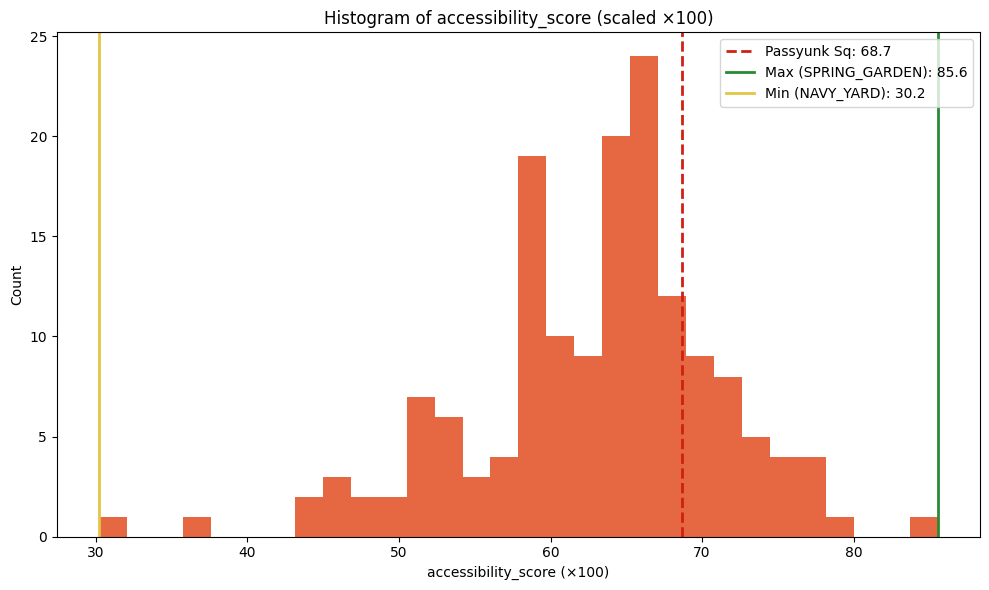

In [284]:
import matplotlib.pyplot as plt

var = "accessibility_score"            # <-- replace with your metric column
name_col = "Name"   # <-- replace with your name column

# --- get values (multiply by 100) ---
gdf["_val"] = gdf[var] * 100

passyunk_value = gdf.loc[gdf[name_col].str.contains("passyunk_square", case=False), "_val"].iloc[0]

max_row = gdf.loc[gdf["_val"].idxmax()]
min_row = gdf.loc[gdf["_val"].idxmin()]

max_value = max_row["_val"]
min_value = min_row["_val"]

max_name = max_row[name_col]
min_name = min_row[name_col]

# --- plot ---
plt.figure(figsize=(10,6))
plt.hist(gdf["_val"], bins=30, color= '#E56843')

# Passyunk Square
plt.axvline(passyunk_value, linestyle="--", linewidth=2, color="#CF2111",
            label=f"Passyunk Sq: {passyunk_value:.1f}")

# Max neighborhood
plt.axvline(max_value, color="#288A32", linewidth=2,
            label=f"Max ({max_name}): {max_value:.1f}")

# Min neighborhood
plt.axvline(min_value, color="#E5C543", linewidth=2,
            label=f"Min ({min_name}): {min_value:.1f}")

plt.xlabel(f"{var} (×100)")
plt.ylabel("Count")
plt.title(f"Histogram of {var} (scaled ×100)")
plt.legend()
plt.tight_layout()
plt.show()
